In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
!pip install xgboost imbalanced-learn

In [3]:
df = pd.read_csv("creditcard.csv")

print("Dataset loaded successfully")
print(df.head())

Dataset loaded successfully
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["Class"].value_counts())

Shape: (284807, 31)

Columns:
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [22]:
# separate x and y

In [5]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 30)
y shape: (284807,)


In [23]:
# split the data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


In [24]:
# applying smote

In [7]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [25]:
# train xgboost

In [8]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train_smote, y_train_smote)

print("XGBoost model trained successfully")


XGBoost model trained successfully


In [26]:
# making prediction

In [9]:
y_prob = model.predict_proba(X_test)[:, 1]

print(y_prob[:10])

[0.00108372 0.0001987  0.0016187  0.00028127 0.00420754 0.00151704
 0.00041273 0.00109565 0.00214819 0.00065946]


In [27]:
# evaluate the model

In [10]:
y_pred = (y_prob >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.99750711000316
Precision: 0.39908256880733944
Recall: 0.8877551020408163
F1 Score: 0.5506329113924051

Confusion Matrix:
[[56733   131]
 [   11    87]]


In [11]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.40      0.89      0.55        98

    accuracy                           1.00     56962
   macro avg       0.70      0.94      0.77     56962
weighted avg       1.00      1.00      1.00     56962



In [29]:
# confusion matrix

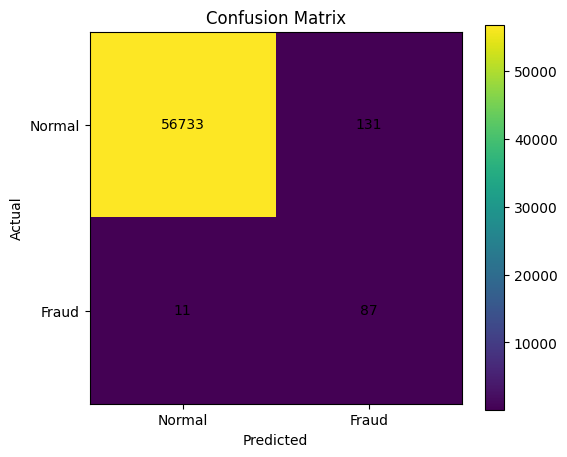

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.xticks([0, 1], ["Normal", "Fraud"])
plt.yticks([0, 1], ["Normal", "Fraud"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [30]:
# tuning the decision threshold

In [13]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    print("Threshold:", threshold)
    print("Precision:", round(precision_score(y_test, y_pred_threshold), 4))
    print("Recall:", round(recall_score(y_test, y_pred_threshold), 4))
    print("F1 Score:", round(f1_score(y_test, y_pred_threshold), 4))
    print()

Threshold: 0.1
Precision: 0.0879
Recall: 0.9082
F1 Score: 0.1604

Threshold: 0.2
Precision: 0.1627
Recall: 0.9082
F1 Score: 0.276

Threshold: 0.3
Precision: 0.2399
Recall: 0.9082
F1 Score: 0.3795

Threshold: 0.4
Precision: 0.3154
Recall: 0.898
F1 Score: 0.4668

Threshold: 0.5
Precision: 0.3991
Recall: 0.8878
F1 Score: 0.5506



In [31]:
# feature importance

In [14]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

   Feature  Importance
14     V14    0.586150
4       V4    0.049288
17     V17    0.035788
10     V10    0.035406
12     V12    0.033213
3       V3    0.020850
8       V8    0.018531
13     V13    0.016901
1       V1    0.015360
23     V23    0.011889


In [32]:
# ploting it

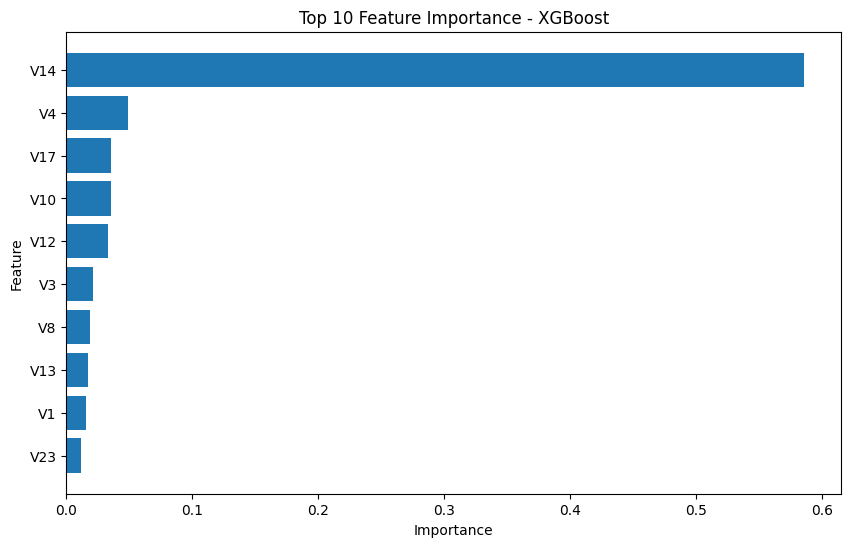

In [15]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"].head(10),
    feature_importance["Importance"].head(10)
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - XGBoost")
plt.gca().invert_yaxis()

plt.show()


In [35]:
# automatically compare the threshold

In [34]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

results = []

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

print(results_df)

   Threshold  Precision    Recall  F1 Score
0        0.1   0.087945  0.908163  0.160360
1        0.2   0.162706  0.908163  0.275969
2        0.3   0.239892  0.908163  0.379531
3        0.4   0.315412  0.897959  0.466844
4        0.5   0.399083  0.887755  0.550633


In [36]:
# find the threshold with the highest f1

In [17]:
best_row = results_df.loc[results_df["F1 Score"].idxmax()]

print("Best Threshold:", best_row["Threshold"])
print("Precision:", best_row["Precision"])
print("Recall:", best_row["Recall"])
print("F1 Score:", best_row["F1 Score"])

Best Threshold: 0.5
Precision: 0.39908256880733944
Recall: 0.8877551020408163
F1 Score: 0.5506329113924051


In [37]:
# final prediction using thr selected threshold

In [18]:
best_threshold = best_row["Threshold"]

final_pred = (y_prob >= best_threshold).astype(int)

print("Final Threshold:", best_threshold)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))

print("\nClassification Report:")
print(classification_report(y_test, final_pred))

Final Threshold: 0.5

Confusion Matrix:
[[56733   131]
 [   11    87]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.40      0.89      0.55        98

    accuracy                           1.00     56962
   macro avg       0.70      0.94      0.77     56962
weighted avg       1.00      1.00      1.00     56962



In [38]:
# get TP,TN,FP,FN separately

In [19]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    final_pred
).ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 56733
FP: 131
FN: 11
TP: 87


In [39]:
# final feature importance

In [20]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
   Feature  Importance
14     V14    0.586150
4       V4    0.049288
17     V17    0.035788
10     V10    0.035406
12     V12    0.033213
3       V3    0.020850
8       V8    0.018531
13     V13    0.016901
1       V1    0.015360
23     V23    0.011889


In [40]:
# plot

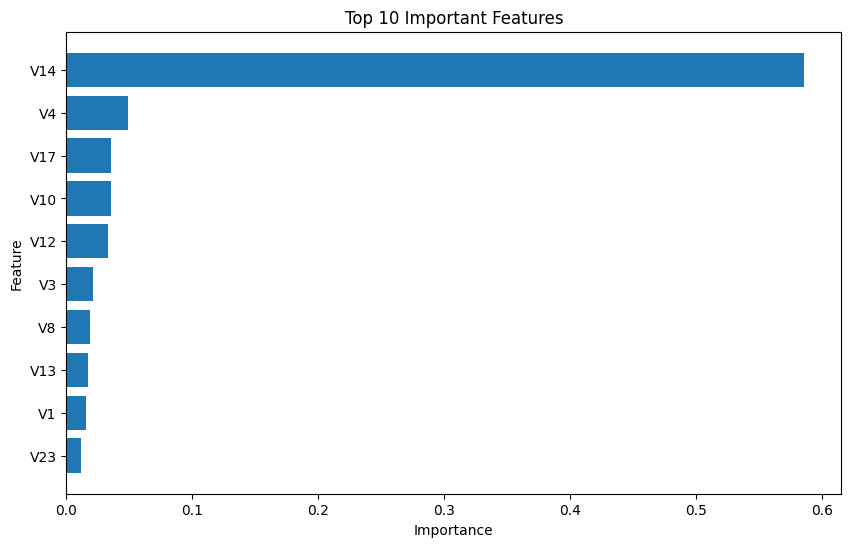

In [21]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()